In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [3]:
data = pd.read_csv('airline-passengers.csv')
data.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


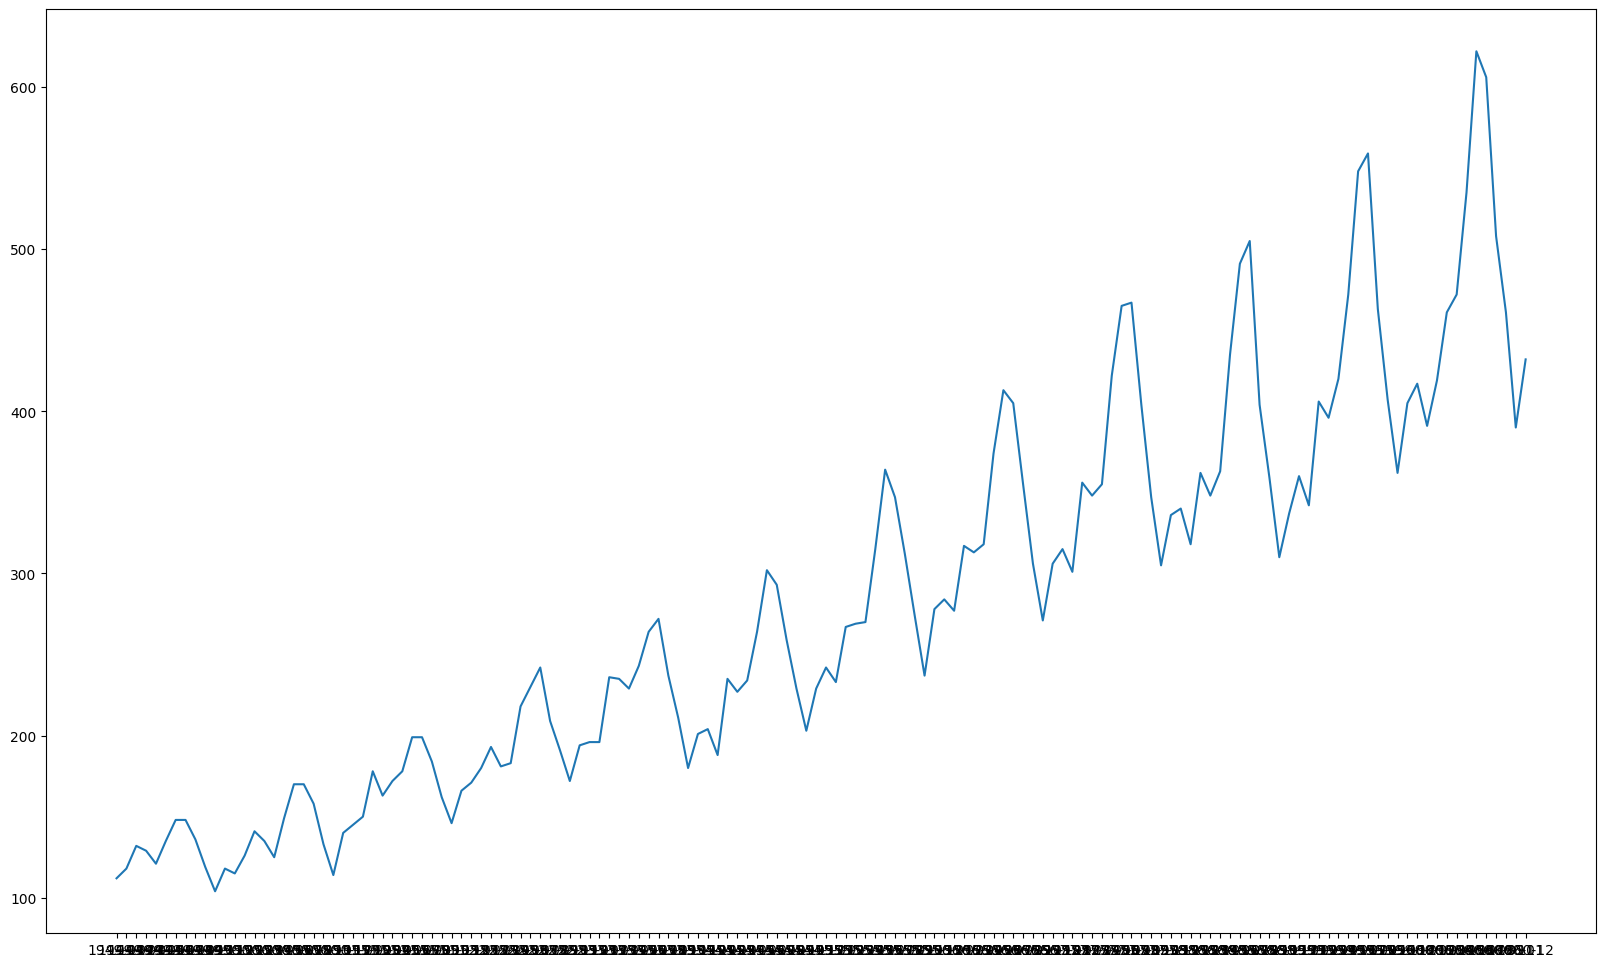

In [4]:
plt.figure(figsize=(20, 12))
plt.plot(data['Month'], data['Passengers'])
plt.show()

In [5]:
adfuller(data['Passengers']) # Check stationarity

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [6]:
data['Passengers'] = np.log(data['Passengers'])

In [7]:
adfuller(data['Passengers']) # Check stationarity

(np.float64(-1.7170170891069683),
 np.float64(0.4223667747703874),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(-445.3990312497209))

In [9]:
data['Passengers'] = np.log(data['Passengers']).diff(1)

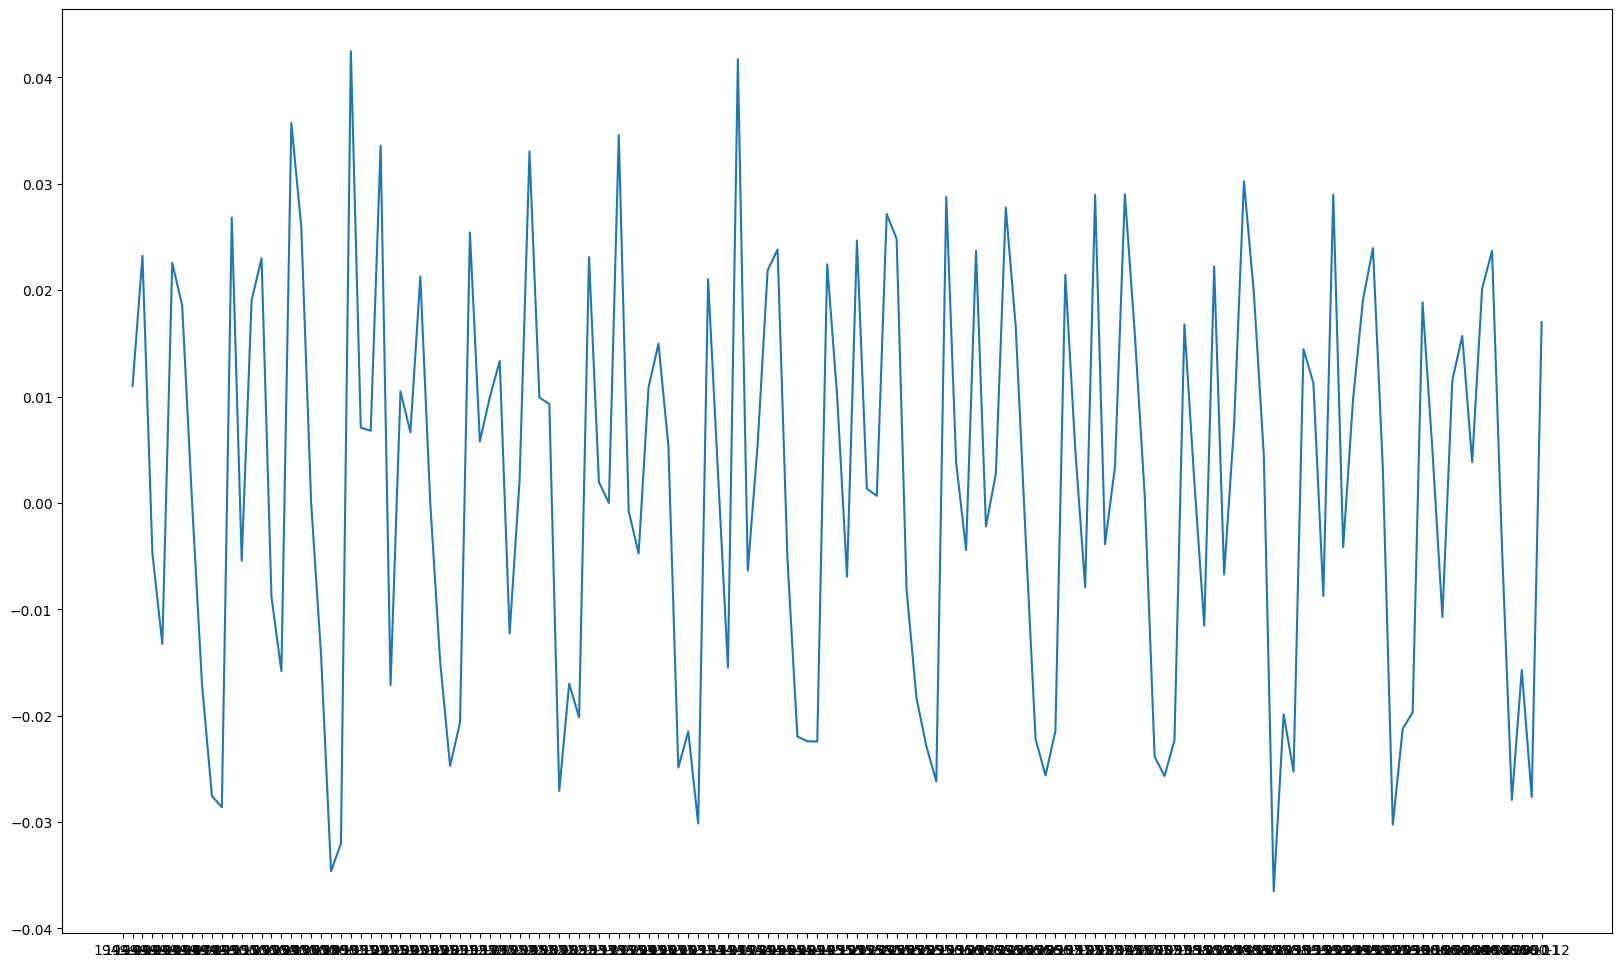

In [10]:
plt.figure(figsize=(20, 12))
plt.plot(data['Month'], data['Passengers'])
plt.show()

In [11]:
data = data.drop(data.index[0])
adfuller(data['Passengers']) # Check stationarity

(np.float64(-2.5017076732182133),
 np.float64(0.11505938212260042),
 14,
 128,
 {'1%': np.float64(-3.4825006939887997),
  '5%': np.float64(-2.884397984161377),
  '10%': np.float64(-2.578960197753906)},
 np.float64(-869.8469847531351))

In [12]:
y = data['Passengers']
train_size = int(len(y) * 0.8)   # 80% train, 20% test
train, test = y.iloc[:train_size], y.iloc[train_size:]

In [ ]:
model = SARIMAX(train, order=(3, 1, 3), seasonal_order=(2, 1, 1, 12))
model_fit = model.fit()

In [14]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                           Passengers   No. Observations:                  114
Model:             SARIMAX(3, 1, 3)x(2, 1, [1], 12)   Log Likelihood                 348.772
Date:                              Sat, 27 Sep 2025   AIC                           -677.544
Time:                                      06:24:20   BIC                           -651.393
Sample:                                           0   HQIC                          -666.957
                                              - 114                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7127      1.150     -0.620      0.535      -2.967       1.541
ar.L2         -1.0058      1.361     -0.739      0.460      -3.673       1.662
ar.L3         -0.3425      0.433     -0.791      0.429      -1.191       0.506
ma.L1         -0.6007      1.154     -0.520      0.603      -2.863       1.662
ma.L2          0.5612      1.444      0.389      0.698      -2.270       3.392
ma.L3         -0.8216      1.148     -0.716      0.474      -3.072       1.428
ar.S.L12      -0.4082      0.630     -0.648      0.517      -1.642       0.826
ar.S.L24      -0.1449      0.293     -0.494      0.622      -0.720       0.430
ma.S.L12      -0.1526      0.649     -0.235      0.814      -1.425       1.120
sigma2      5.545e-05   9.17e-06      6.044      0.000    3.75e-05    7.34e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 0.04
Prob(Q):                              0.80   Prob(JB):                         0.98
Heteroskedasticity (H):               0.17   Skew:                            -0.04
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [15]:
data['sarimax'] = model_fit.fittedvalues

In [16]:
data

,Month,Passengers,sarimax
1,1949-02,0.010999,0.000000
2,1949-03,0.023229,0.010999
3,1949-04,-0.004719,0.023229
4,1949-05,-0.013261,-0.004719
5,1949-06,0.022573,-0.013261
...,...,...,...
139,1960-08,-0.004059,NaN
140,1960-09,-0.027919,NaN
141,1960-10,-0.015705,NaN
142,1960-11,-0.027648,NaN


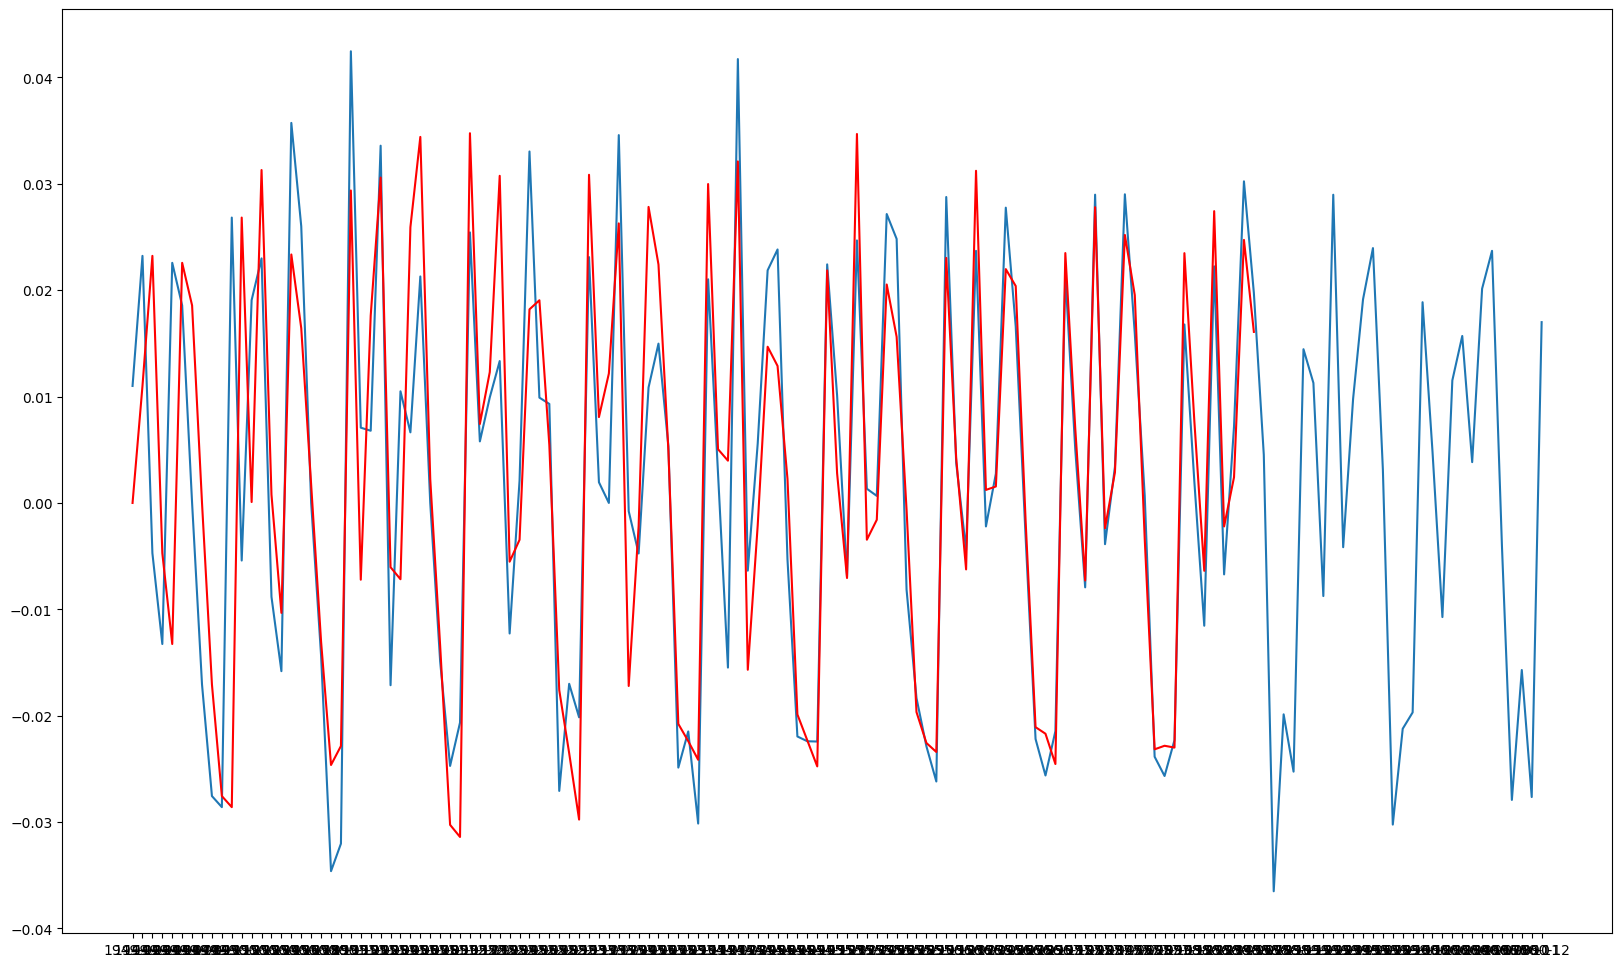

In [18]:
plt.figure(figsize=(20, 12))
plt.plot(data['Month'], data['Passengers'])
plt.plot(data['Month'], data['sarimax'], c='red')
plt.show()

In [19]:
data.loc[:4, 'sarimax'] = np.nan
forcast = model_fit.predict(12)

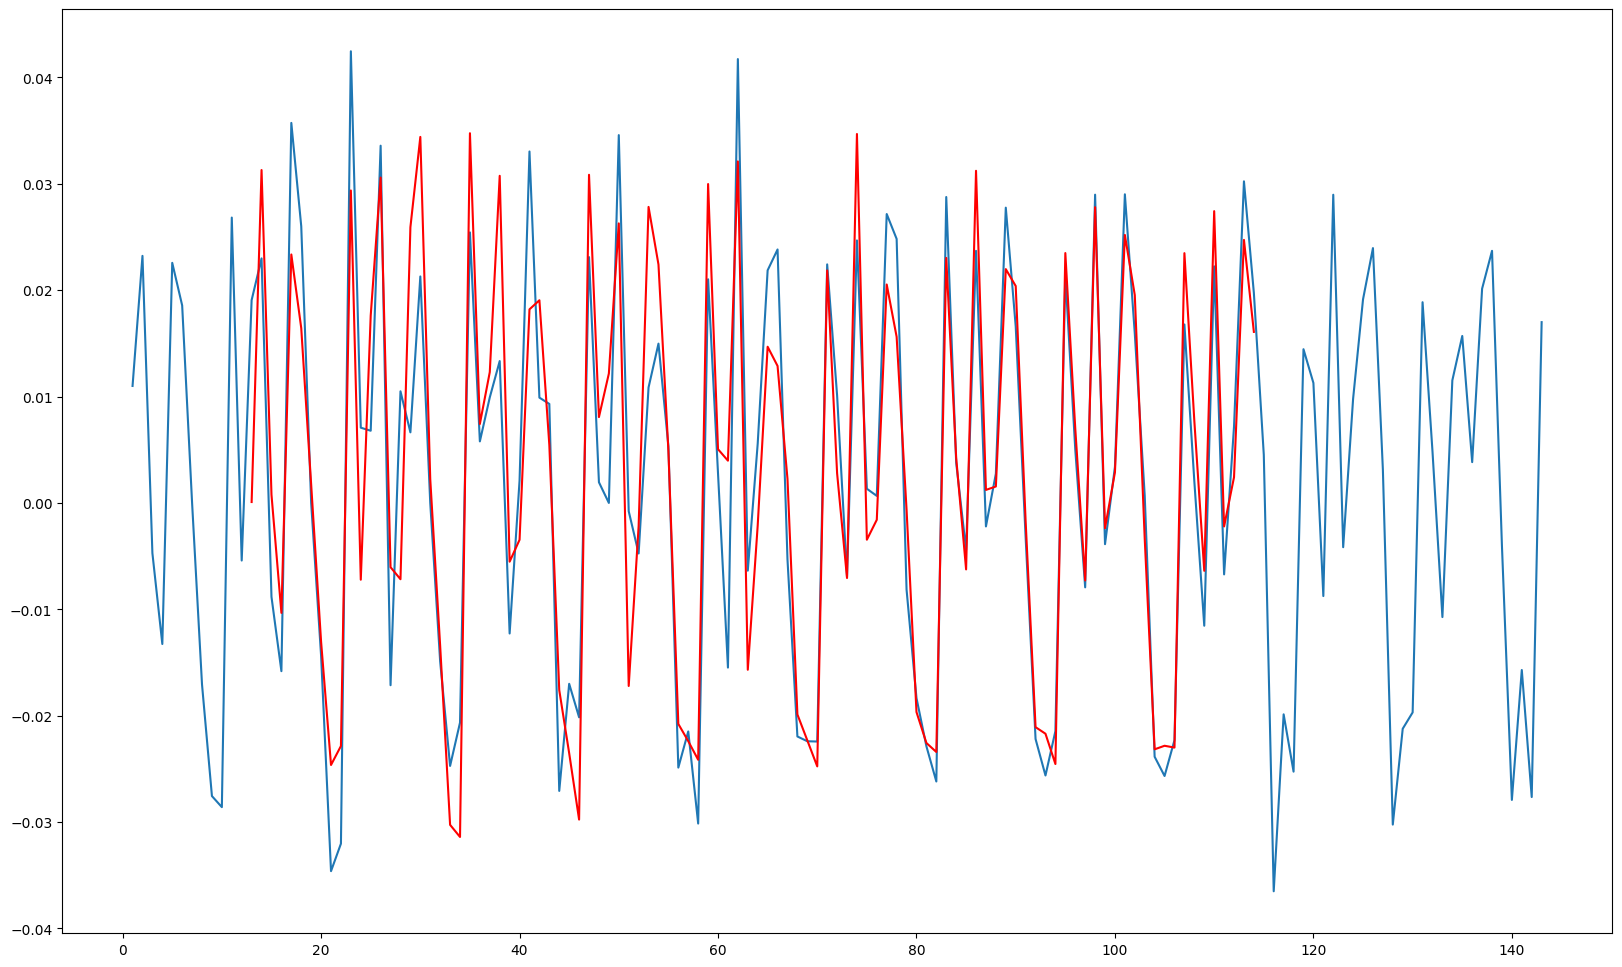

In [20]:
plt.figure(figsize=(20, 12))
plt.plot(data['Passengers'])
plt.plot(forcast, color="Red")
plt.show()

In [21]:
forecast = pd.concat([data['sarimax'], forcast])


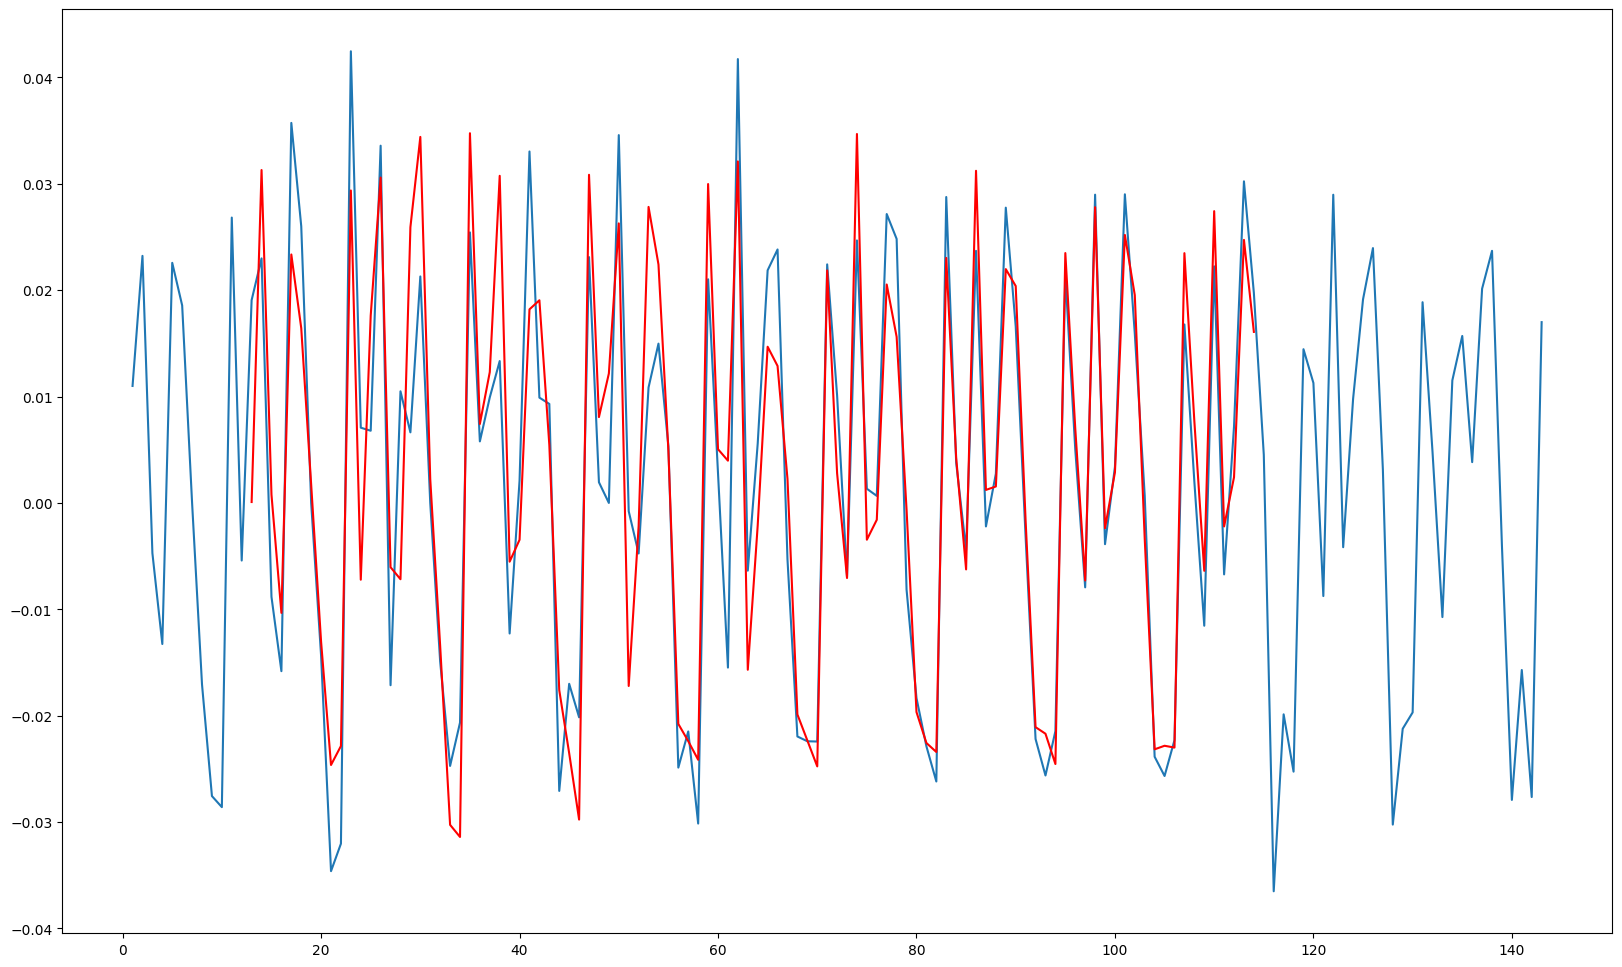

In [22]:
plt.figure(figsize=(20, 12))
plt.plot(data['Passengers'])
plt.plot(forcast, color="Red")
plt.show()

RMSE = 0.007, MAE = 0.006


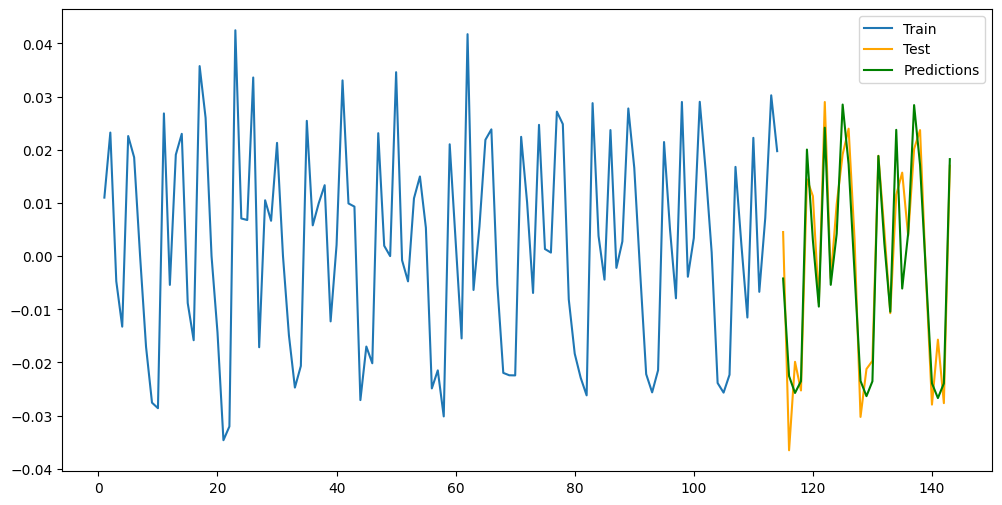

In [25]:
# - Predict on test ---
pred = model_fit.get_forecast(steps=len(test))
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

# - Evaluation ---
rmse = np.sqrt(mean_squared_error(test, pred_mean))
mae = mean_absolute_error(test, pred_mean)
print(f"RMSE = {rmse:.3f}, MAE = {mae:.3f}")

# - Plot train/test/pred ---
plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Test", color="orange")
plt.plot(pred_mean, label="Predictions", color="green")
plt.legend()
plt.show()

Future forecast:
144    0.001876
145   -0.010959
146    0.023039
147   -0.006624
148    0.004046
149    0.028096
150    0.016939
151   -0.004150
152   -0.024205
153   -0.027051
154   -0.024378
155    0.018037
156    0.001576
157   -0.011216
158    0.022769
159   -0.006917
160    0.003524
161    0.027625
162    0.016422
163   -0.004448
164   -0.024623
165   -0.027462
166   -0.024749
167    0.017602
Name: predicted_mean, dtype: float64


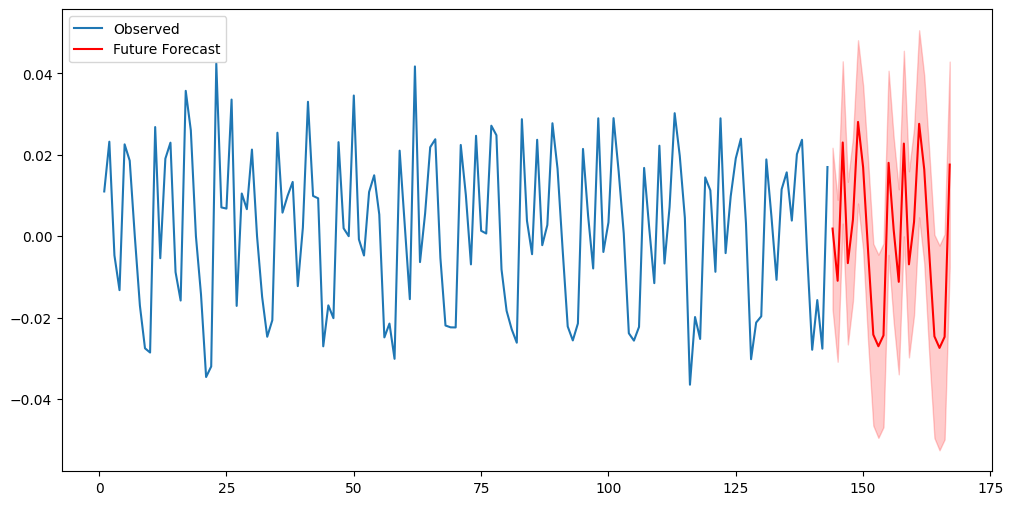

In [26]:
#Forecast future (e.g. next 24 months) ---
future_steps = 24
future_forecast = model_fit.get_forecast(steps=len(test)+future_steps)
future_mean = future_forecast.predicted_mean[-future_steps:]
future_ci = future_forecast.conf_int().iloc[-future_steps:]

print("Future forecast:")
print(future_mean)

plt.figure(figsize=(12,6))
plt.plot(y, label="Observed")
plt.plot(future_mean.index, future_mean, label="Future Forecast", color="red")
plt.fill_between(future_ci.index,
                 future_ci.iloc[:,0],
                 future_ci.iloc[:,1],
                 color='red', alpha=0.2)
plt.legend()
plt.show()